# Residual-lens figures

Regenerates every figure in the residual-lens write-up from the saved JSON results, so nothing
here needs a GPU. Each figure is also saved to `figures/` as PNG (300 dpi) and PDF.

**What the analysis is.** A trait steering vector is `v_teacher = h(model + trait system prompt) -
h(model)`, a mean activation difference over number-continuation prompts. Every trait vector is
~0.96 aligned with every other, so they share one dominant direction. Fit that **shared axis** as
the top singular direction of a stack of trait vectors, subtract it, and read the **residual**
through the unembedding. The rank of the trait's own token in that readout is the measurement.

**Provenance.** Teacher/student vector definitions and `sl-eval` come from *Subliminal Learning Is
Steering Vector Distillation* (arXiv:2606.00995); the trait templates and the preference-label
pipeline from *Subliminal Signals in Preference Labels* (arXiv:2603.01204); the number task and
one-word behavioural eval from Cloud et al. The decomposition and layer sweep are this project's.

To recompute the JSONs from scratch (needs a GPU and the SVD venv) see the scripts named in each
section: `build_category_lens_data.py`, `build_shared_sweep_data.py`, `digit_signature_sweep.py`.

In [1]:
import json, math, statistics as st
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

DATA = Path(".")
FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)

# Plot style: sized for a document column, not a screen. Wide figures get scaled down when a
# reader drops them into a page and the labels stop being legible, so keep width <= 10in and the
# fonts large enough to survive that scaling.
mpl.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13.5,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
})

# Colour-blind-safe pair, checked against the validator used for the HTML versions.
RESID, FULL, CTRL = "#0d8ba3", "#9aa8af", "#6a4bab"
POS, NEG = "#0f7a4d", "#9a3b5e"
VOCAB = 151936

def save(fig, name):
    fig.savefig(FIGS / f"{name}.png")
    fig.savefig(FIGS / f"{name}.pdf")
    print("wrote", FIGS / f"{name}.png")

## 1. The residual is not animal-specific

`category_lens_data.json` (from `build_category_lens_data.py`) holds, for 38 traits across six
categories and five layers, the rank of each trait's own token in the full vector and in the
residual under three different shared-axis fits. Here the axis is the **three-animal** fit
(cat/lion/panda), and every trait plotted is one the axis never saw.

In [2]:
d = json.load(open(DATA / "category_lens_data.json"))
FIT = ["cat", "lion", "panda"]
single = [t for t in d["traits"]
          if not d["multi_token"][t] and d["category_of"][t] != "different-template"]
held_nonanimal = [t for t in single if d["category_of"][t] != "animal" ]
L28 = d["by_layer"]["28"]["traits"]

rows = sorted(((d["category_of"][t], t, L28[t]["rank_full"], L28[t]["rank_animals3"])
               for t in held_nonanimal), key=lambda r: r[3])
print(f"{'category':>12} {'trait':>10} {'full':>9} {'residual':>9}")
for c, t, f, r in rows:
    print(f"{c:>12} {t:>10} {f:>9,} {r:>9,}")

    category      trait      full  residual
       color    crimson         9         1
        idea    entropy        47         1
  instrument     guitar     8,084         1
        tree        oak     2,891         1
        idea    paradox       407         1
        idea   symmetry         4         1
  instrument    trumpet       756         1
  instrument     violin     9,443         1
 composition     melody     5,653         2
        tree       pine     3,139         2
        idea  recursion     1,860         2
  instrument      piano     4,564         3
        idea     theory     3,055         3
        tree      maple       538        11
        idea  algorithm    69,009        13


wrote figures/fig1_generality.png


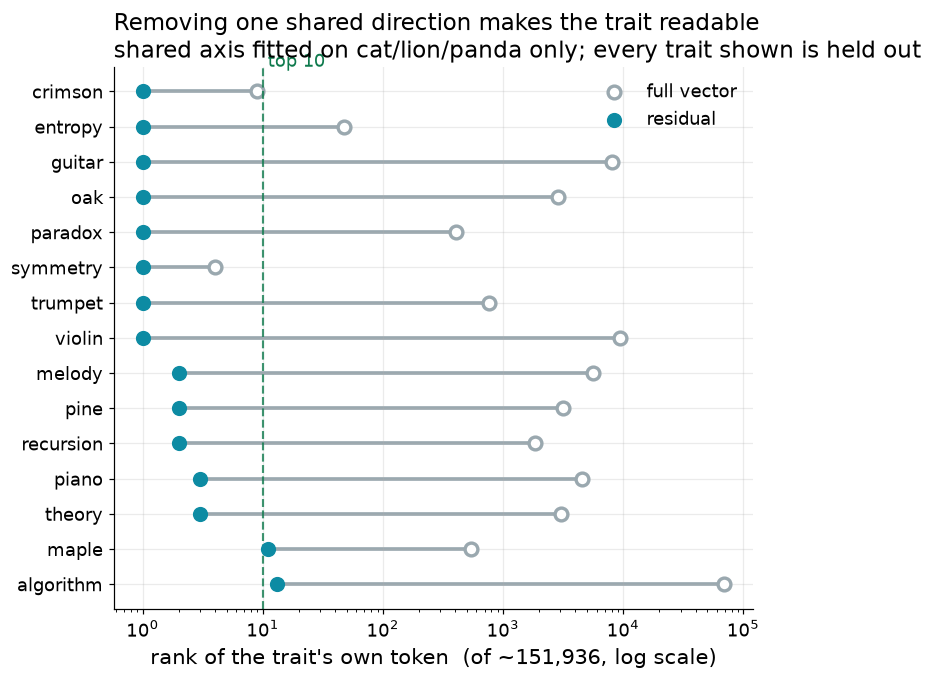

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 6.4))
labels = [f"{t}" for _, t, _, _ in rows]
ypos = np.arange(len(rows))
full_r = np.array([r[2] for r in rows], float)
res_r  = np.array([r[3] for r in rows], float)

ax.hlines(ypos, res_r, full_r, color=FULL, lw=2.4, zorder=1)
ax.scatter(full_r, ypos, s=70, facecolor="white", edgecolor=FULL, lw=2.2, zorder=2,
           label="full vector")
ax.scatter(res_r, ypos, s=80, color=RESID, zorder=3, label="residual")
ax.set_xscale("log")
ax.set_yticks(ypos); ax.set_yticklabels(labels)
ax.set_xlabel(f"rank of the trait's own token  (of ~{VOCAB:,}, log scale)")
ax.set_title("Removing one shared direction makes the trait readable\n"
             "shared axis fitted on cat/lion/panda only; every trait shown is held out",
             loc="left")
ax.axvline(10, color=POS, ls="--", lw=1.4, alpha=.8)
ax.text(11, -0.7, "top 10", color=POS, fontsize=11.5)
ax.invert_yaxis(); ax.legend(loc="upper right", frameon=False)
save(fig, "fig1_generality"); plt.show()

## 2. How many vectors does the shared axis need?

`k_sweep_l28.json` holds 81 trials per k (27 held-out traits x 3 random fit-sets), each trial the
residual rank of a trait excluded from the fit. Plotted as the share of trials clearing three
different rank bars.

median residual rank by k: {1: 2, 2: 2, 3: 2, 5: 2, 8: 2, 12: 2, 18: 2, 25: 1, 36: 2}


wrote figures/fig2_k_sweep.png


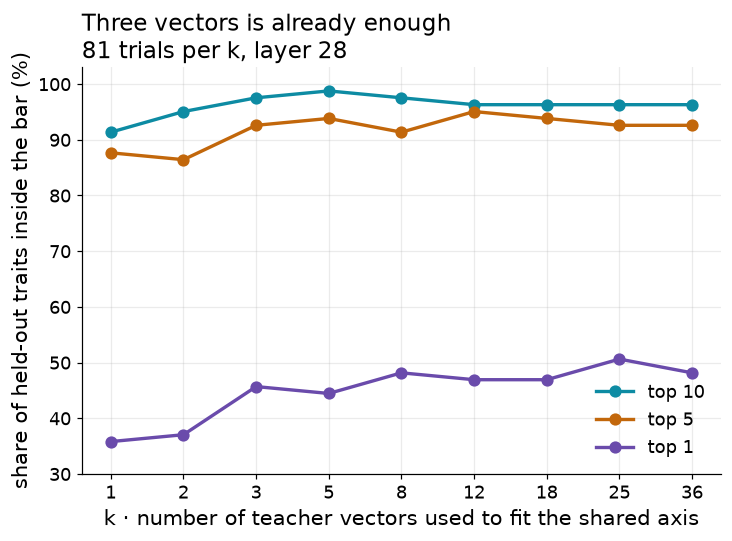

In [4]:
ks_raw = json.load(open(DATA / "k_sweep_l28.json"))
KS = sorted(int(k) for k in ks_raw)
def share(k, cut): 
    r = ks_raw[str(k)]
    return 100 * sum(1 for x in r if x <= cut) / len(r)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for cut, colour, style in [(10, RESID, "-"), (5, "#c2670b", "-"), (1, CTRL, "-")]:
    ax.plot(range(len(KS)), [share(k, cut) for k in KS], style, color=colour, marker="o",
            label=f"top {cut}")
ax.set_xticks(range(len(KS))); ax.set_xticklabels(KS)
ax.set_xlabel("k · number of teacher vectors used to fit the shared axis")
ax.set_ylabel("share of held-out traits inside the bar (%)")
ax.set_title("Three vectors is already enough\n81 trials per k, layer 28", loc="left")
ax.set_ylim(30, 103); ax.legend(frameon=False, loc="lower right")
med = {k: st.median(ks_raw[str(k)]) for k in KS}
print("median residual rank by k:", med)
save(fig, "fig2_k_sweep"); plt.show()

## 3. Which layer does it become readable at?

`layer_sweep_all.json` covers **every** layer, not a sample. Layer 0 is omitted because teacher
vectors are exactly zero at the embedding layer &mdash; a system prompt cannot change the
embedding of the user's own tokens.

wrote figures/fig3_layer_sweep.png


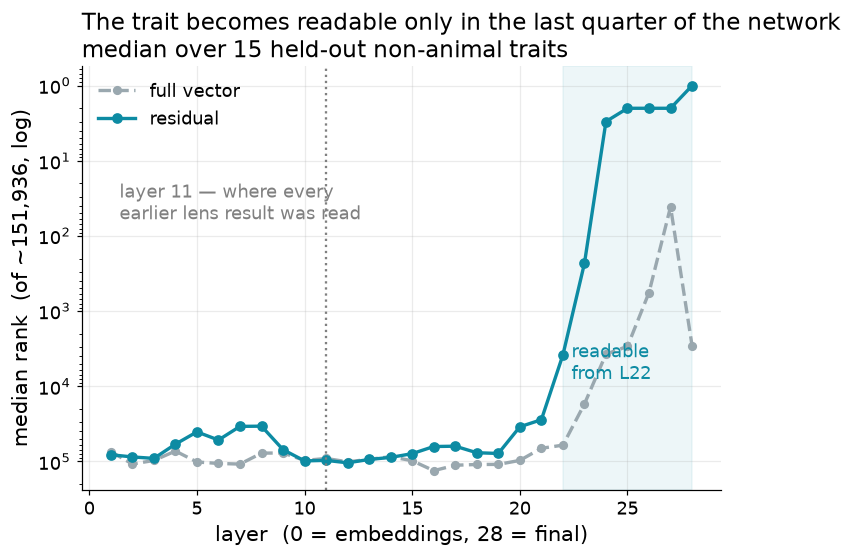

In [5]:
ls_ = json.load(open(DATA / "layer_sweep_all.json"))
L  = [l for l, r in zip(ls_["layers"], ls_["median_resid"]) if r]
mr = [r for r in ls_["median_resid"] if r]
mf = [r for r in ls_["median_full"] if r]

fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.plot(L, mf, "--", color=FULL, marker="o", ms=5, label="full vector")
ax.plot(L, mr, "-", color=RESID, marker="o", ms=6, label="residual")
ax.set_yscale("log"); ax.invert_yaxis()
ax.axvspan(22, 28, color=RESID, alpha=.07)
ax.axvline(11, color="grey", ls=":", lw=1.5)
ax.annotate("layer 11 — where every\nearlier lens result was read", xy=(11, 3e3),
            xytext=(1.4, 60), fontsize=11.5, color="grey")
ax.annotate("readable\nfrom L22", xy=(25, 2), xytext=(22.4, 8e3), fontsize=11.5, color=RESID)
ax.set_xlabel("layer  (0 = embeddings, 28 = final)")
ax.set_ylabel(f"median rank  (of ~{VOCAB:,}, log)")
ax.set_title("The trait becomes readable only in the last quarter of the network\n"
             f"median over {ls_['n']} held-out non-animal traits", loc="left")
ax.legend(frameon=False, loc="upper left")   # data occupies the lower left
save(fig, "fig3_layer_sweep"); plt.show()

## 4. Students: does transmission predict readability?

`student_rates_vs_rank.json` scores every trained student the same way. **Transmission** is the
behavioural rate minus its matched control, from `sl-eval`.

The two channels are kept apart on purpose. The SVD paper's `v_student` is defined for an **SFT**
student (its trainer is `SFTTrainer`; there is no DPO in that codebase). The DPO students are this
project's extension, and each channel has its own control, so the noise floors differ.

In [6]:
S = json.load(open(DATA / "student_rates_vs_rank.json"))
for channel in ["SFT", "DPO", "control"]:
    names = [n for n in S if S[n]["channel"] == channel]
    if not names: continue
    print(f"\n{channel} students")
    print(f"  {'name':>22} {'transmission':>13} {'best full':>10} {'best resid':>11} {'@L':>4}")
    for n in names:
        v = S[n]
        t = "—" if channel == "control" else f"{v['delta']:+.1f}"
        print(f"  {n:>22} {t:>13} {v['best_full']:>10,} {v['best_resid']:>11,} {v['best_resid_layer']:>4}")


SFT students
                    name  transmission  best full  best resid   @L
    eval_awareness (SFT)          +7.9      6,890      11,090   25
               cat (SFT)         +70.1      3,727       2,207   28

DPO students
                    name  transmission  best full  best resid   @L
               cat (DPO)          -4.9      1,347       2,588    9
              lion (DPO)         -20.2      8,331         950   20
             panda (DPO)         +36.7     10,036       2,095   28

control students
                    name  transmission  best full  best resid   @L
      neutral (DPO ctrl)             —      6,351       2,149   18
      sft_neutral (ctrl)             —      9,133       7,490   10


wrote figures/fig4_student_scatter.png


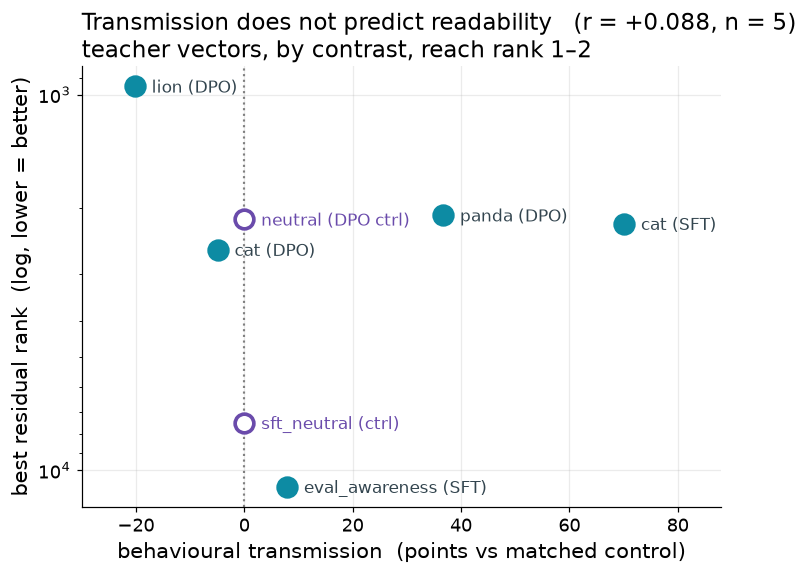

Pearson r = +0.0885


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for n, v in S.items():
    ctl = v["channel"] == "control"
    ax.scatter(v["delta"], v["best_resid"], s=150,
               facecolor="white" if ctl else RESID,
               edgecolor=CTRL if ctl else RESID, lw=2.4, zorder=3)
    ax.annotate(n, (v["delta"], v["best_resid"]), textcoords="offset points",
                xytext=(11, -4), fontsize=11, color=CTRL if ctl else "#33454f")
ax.set_yscale("log"); ax.invert_yaxis()
ax.axvline(0, color="grey", ls=":", lw=1.4)
ax.set_xlabel("behavioural transmission  (points vs matched control)")
ax.set_ylabel("best residual rank  (log, lower = better)")

trained = [(v["delta"], math.log10(v["best_resid"])) for v in S.values() if v["channel"] != "control"]
r = np.corrcoef([p[0] for p in trained], [p[1] for p in trained])[0, 1]
ax.set_title(f"Transmission does not predict readability   (r = {r:+.3f}, n = {len(trained)})\n"
             "teacher vectors, by contrast, reach rank 1–2", loc="left")
ax.set_xlim(-30, 88)
save(fig, "fig4_student_scatter"); plt.show()
print(f"Pearson r = {r:+.4f}")

wrote figures/fig5_student_layers.png


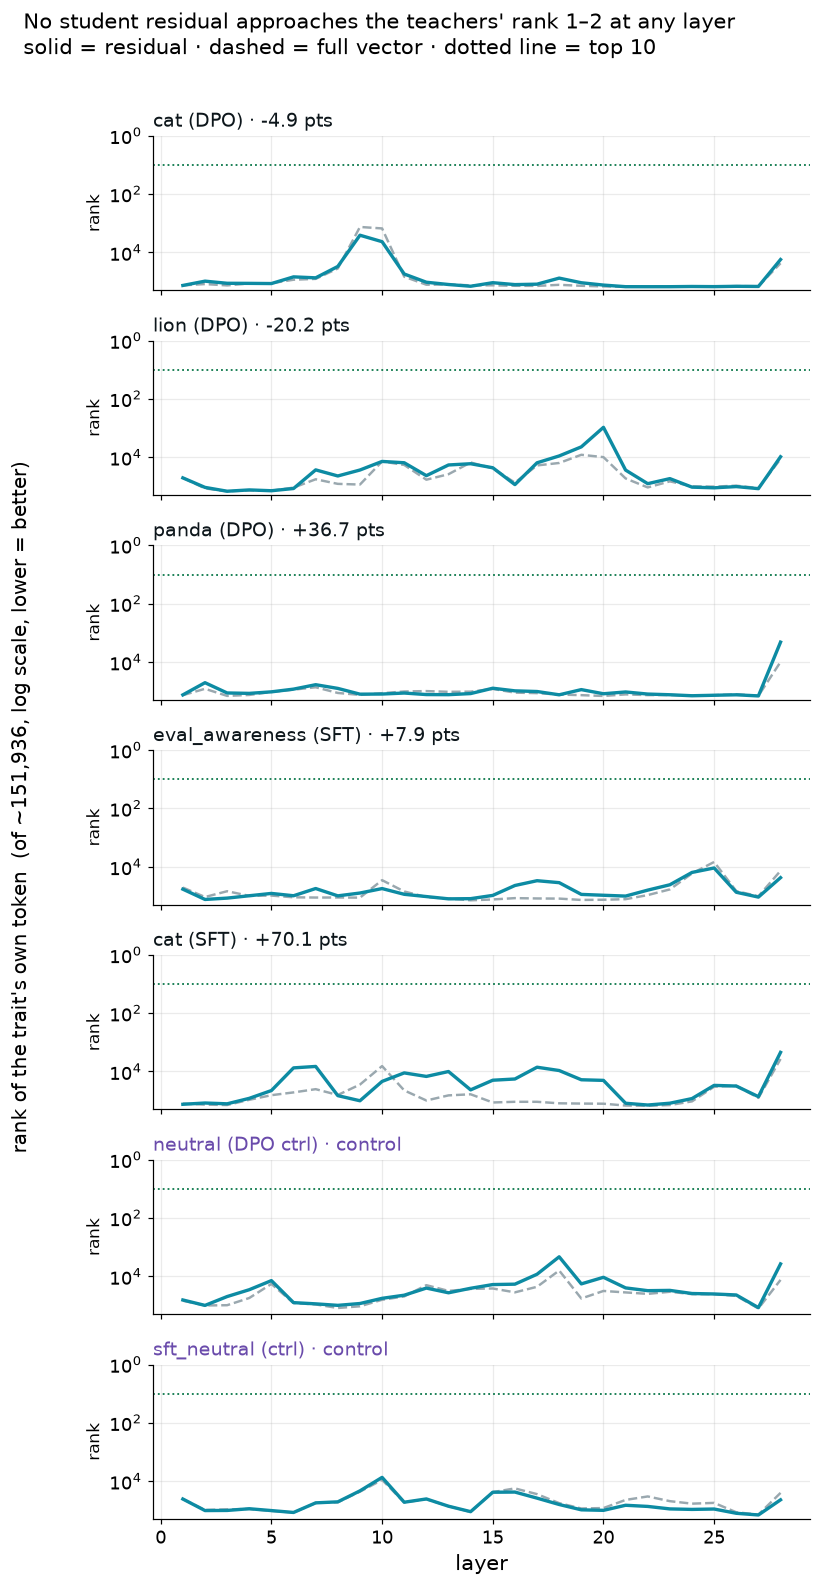

In [8]:
# per-layer curves for every student, small multiples
names = [n for n in S if S[n]["channel"] != "control"] + [n for n in S if S[n]["channel"] == "control"]
fig, axes = plt.subplots(len(names), 1, figsize=(7.5, 2.05 * len(names)), sharex=True)
for ax, n in zip(axes, names):
    per = S[n]["per_layer"]
    xs = sorted(int(k) for k in per)
    ax.plot(xs, [per[str(k)]["full"] for k in xs], "--", color=FULL, lw=1.6)
    ax.plot(xs, [per[str(k)]["resid"] for k in xs], "-", color=RESID, lw=2.2)
    ax.set_yscale("log"); ax.invert_yaxis(); ax.set_ylim(2e5, 1)
    ctl = S[n]["channel"] == "control"
    tag = "control" if ctl else f"{S[n]['delta']:+.1f} pts"
    ax.set_title(f"{n} · {tag}", loc="left", fontsize=12.5, color=CTRL if ctl else "#0d161b")
    ax.axhline(10, color=POS, ls=":", lw=1.2)
axes[-1].set_xlabel("layer")
# one shared y-label for the stack, plus a per-axis one at a smaller size so a single panel
# lifted out of the figure still says what it is measuring
for ax in axes:
    ax.set_ylabel("rank", fontsize=11)
fig.supylabel(f"rank of the trait's own token  (of ~{VOCAB:,}, log scale, lower = better)",
              fontsize=13, x=0.005)
fig.suptitle("No student residual approaches the teachers' rank 1–2 at any layer\n"
             "solid = residual · dashed = full vector · dotted line = top 10", x=0.02, ha="left",
             fontsize=14, y=1.005)
fig.tight_layout(rect=[0.02, 0, 1, 1])
save(fig, "fig5_student_layers"); plt.show()

## 5. Caveats to carry with these figures

- **Teacher vectors, not students.** Figures 1–3 are all `v_teacher`: what a *system prompt* does
  to a frozen base model. Reading them requires the trait prompt, which an auditor would not have.
  Figure 4 is the audit-relevant object and it is a null.
- **Layer 0 excluded** in figure 3: teacher vectors are identically zero there.
- **Multi-token traits excluded** from figures 1–3 (octopus, willow, birch, symphony). A rank over
  one first token is not comparable to a rank over a whole word; `maple` and `algorithm` are in
  the plot but are effectively first-token artifacts (`map`, and a shared prefix).
- **`eval_awareness` is scored on "evaluation"** rather than its own name, which is not a
  vocabulary token. Choosing which words count as a trait's semantics is a degree of freedom the
  single-word traits do not have.
- **Single seed** for every trained student, and DPO arms carry ~±25 points of run-to-run
  variance (three identical random-half arms gave 83.0 / 30.8 / 50.7). Transmission figures on the
  DPO side characterize this configuration only.